In [1]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [2]:
from urllib.request import urlretrieve

In [3]:
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x22a680751c0>)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
df= pd.read_csv('medical.csv')

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [27]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [28]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

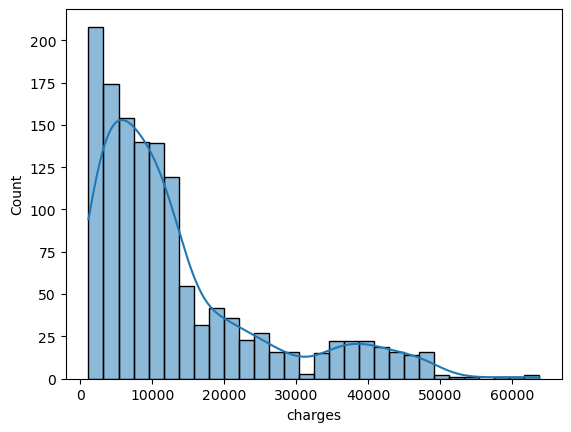

In [26]:
sns.histplot(data=df,x='charges',kde=True)
plt.show()

In [15]:
def try_features(df):
    features = df.select_dtypes(include=np.number).columns
    for feature in features:
        if feature != 'charges':  # Avoid plotting 'charges' against itself
            sns.scatterplot(data=df, x=feature, y='charges')
            plt.title(f'Charges vs {feature}')
            plt.show()


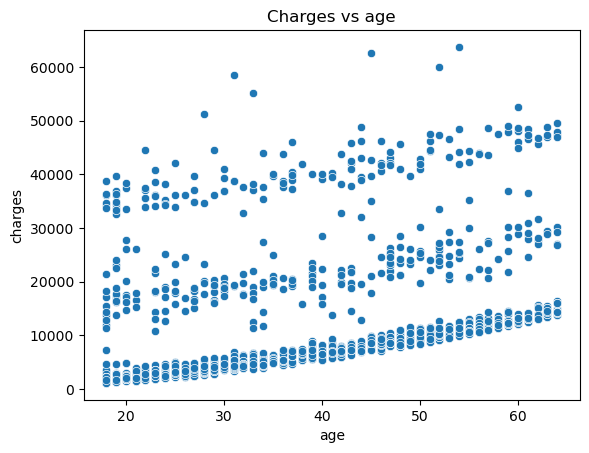

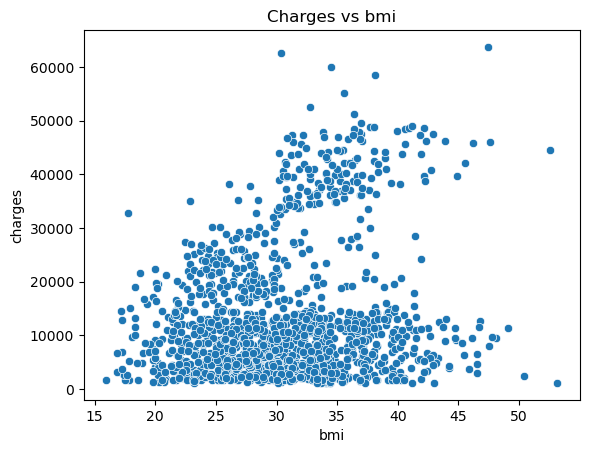

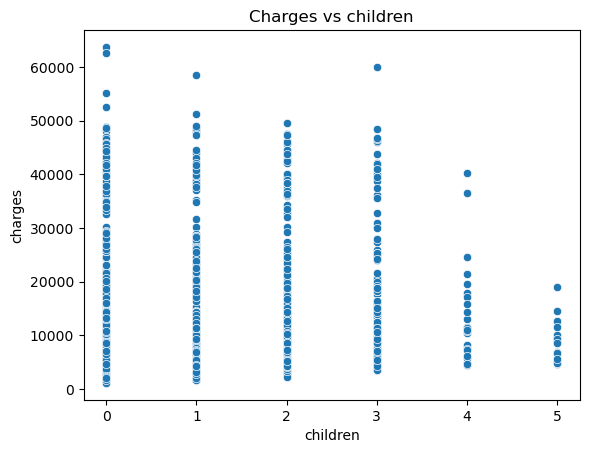

In [19]:
try_features(df)

In [23]:
corr=df.select_dtypes(include=np.number).corr()
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


### Observations
- we can see that `age` having high correlation of `0.29` among all the numerical variables.
- we have to check corr for the `categorical columns` also

In [24]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [29]:
df.smoker.unique()

array(['yes', 'no'], dtype=object)

In [30]:
df.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [31]:
df.sex.unique()

array(['female', 'male'], dtype=object)

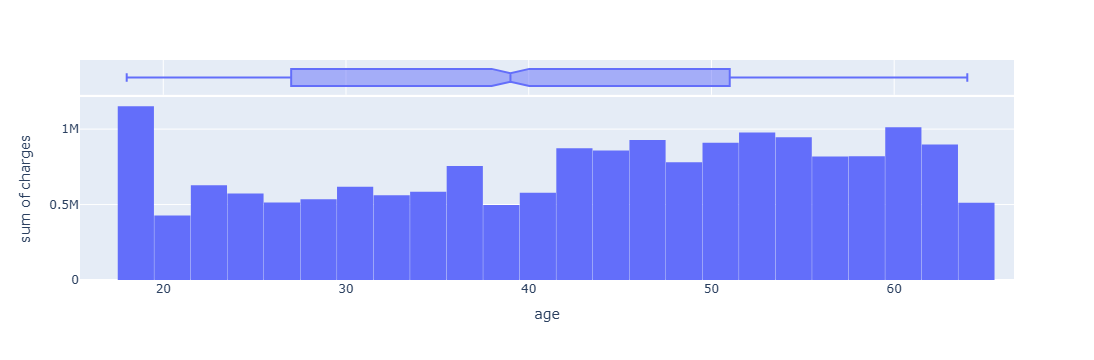

In [34]:
fig = px.histogram(df,x='age',marginal='box',y='charges')
fig.update_layout(bargap=0.01)
fig

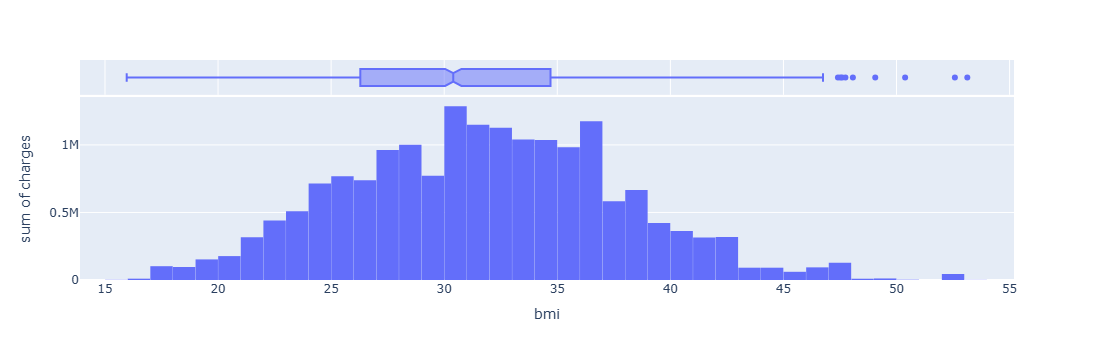

In [37]:
fig=px.histogram(df,x='bmi',y='charges',marginal='box')
fig.update_layout(bargap=0.01)
fig

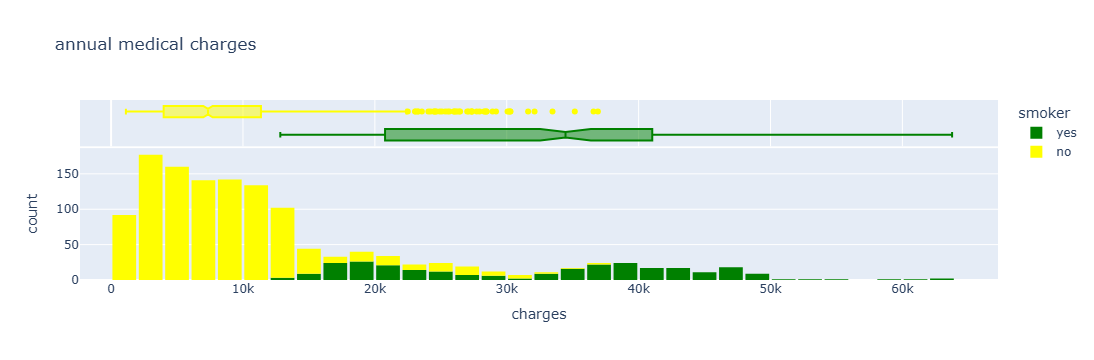

In [39]:
fig3 = px.histogram(df,x='charges',color='smoker',marginal='box',color_discrete_sequence=['green','yellow'],title='annual medical charges')
fig3.update_layout(bargap=0.1)
fig3

## Observations
- we can see that `smokers` are having `high charges` compared to the non-smokers

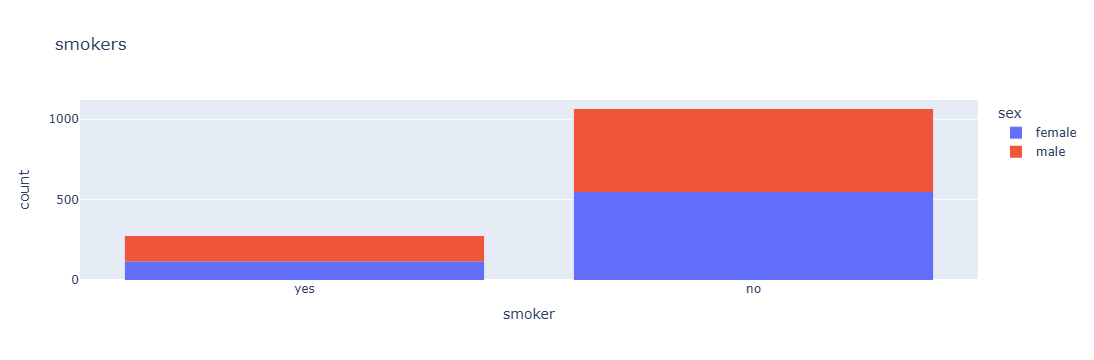

In [42]:
px.histogram(df,x='smoker',color='sex',title='smokers')

## Observations
- male category having the more smokers compared to females

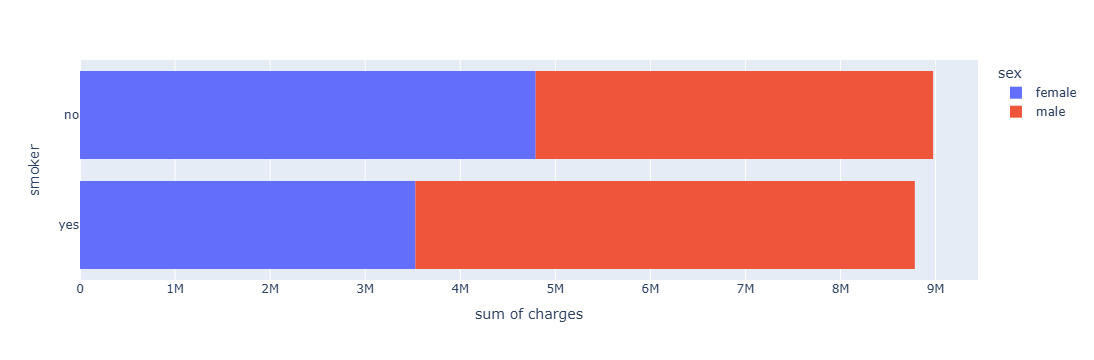

In [46]:
px.histogram(df,x='charges',y='smoker',color='sex')

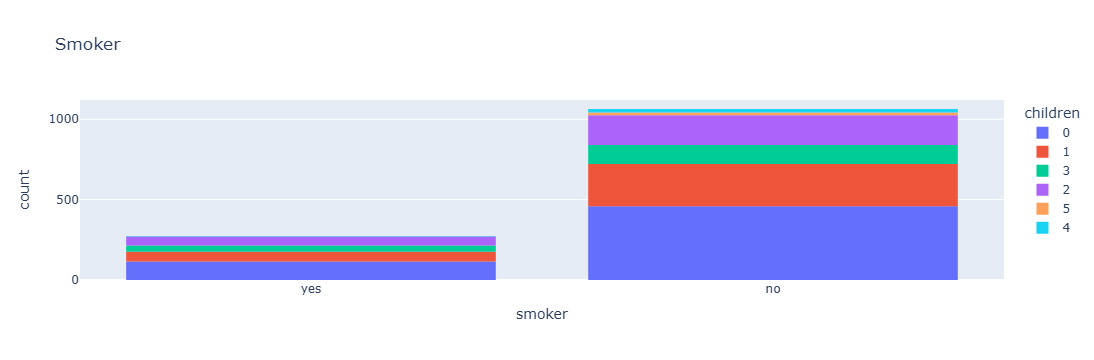

In [48]:
px.histogram(df,x='smoker',color='children',title='Smoker')

## Dealing with the categorical variables
- since there are less unique values in the categorical features we can use map() to convert them in to numerical values.

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [52]:
df['sex'] = df['sex'].map({'male':0,'female':1}).astype('int64')

In [57]:
df['smoker'] = df['smoker'].map({'yes':1,'no':0}).astype('int64')

In [59]:
dummies=pd.get_dummies(df['region'],dtype=int)

In [60]:
df=pd.concat([df,dummies],axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,southwest,16884.92400,0,0,0,1
1,18,0,33.770,1,0,southeast,1725.55230,0,0,1,0
2,28,0,33.000,3,0,southeast,4449.46200,0,0,1,0
3,33,0,22.705,0,0,northwest,21984.47061,0,1,0,0
4,32,0,28.880,0,0,northwest,3866.85520,0,1,0,0


In [56]:
df.smoker.unique()

array(['yes', 'no'], dtype=object)

In [61]:
df=df.drop('region',axis=1)

In [62]:
df.head()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1338 non-null   int64  
 1   sex        1338 non-null   int64  
 2   bmi        1338 non-null   float64
 3   children   1338 non-null   int64  
 4   smoker     1338 non-null   int64  
 5   charges    1338 non-null   float64
 6   northeast  1338 non-null   int32  
 7   northwest  1338 non-null   int32  
 8   southeast  1338 non-null   int32  
 9   southwest  1338 non-null   int32  
dtypes: float64(2), int32(4), int64(4)
memory usage: 83.8 KB


In [65]:
corr=df.corr()
corr

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008,0.002475,-0.000407,-0.011642,0.010016
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292,0.002425,0.011156,-0.017117,0.004184
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341,-0.138156,-0.135996,0.270025,-0.006205
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998,-0.022808,0.024806,-0.023066,0.021914
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251,0.002811,-0.036945,0.068498,-0.036945
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000,0.006349,-0.039905,0.073982,-0.043210
northeast,0.002475,0.002425,-0.138156,-0.022808,0.002811,0.006349,1.000000,-0.320177,-0.345561,-0.320177
northwest,-0.000407,0.011156,-0.135996,0.024806,-0.036945,-0.039905,-0.320177,1.000000,-0.346265,-0.320829
southeast,-0.011642,-0.017117,0.270025,-0.023066,0.068498,0.073982,-0.345561,-0.346265,1.000000,-0.346265
southwest,0.010016,0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320177,-0.320829,-0.346265,1.000000


<Axes: >

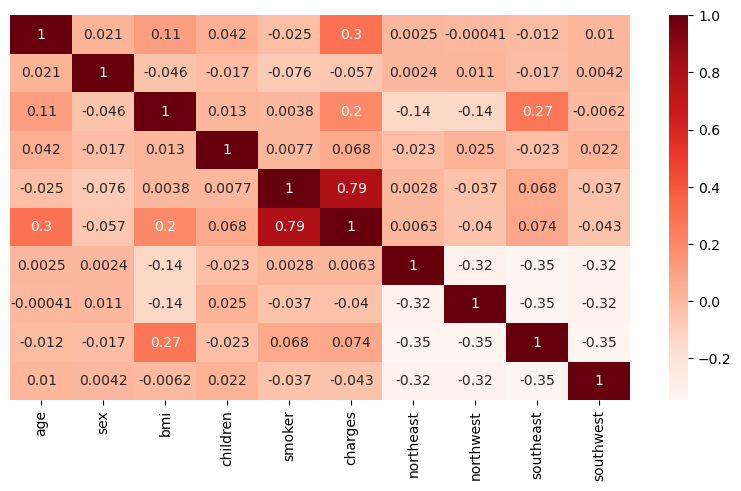

In [71]:
plt.figure(figsize=(10,5))
sns.heatmap(data=df.corr(),cmap='Reds',yticklabels=False,annot=True)


### Observations
- we can see that `smokers` having the `high correlation` of `0.787251` amoung all the features

## considering the inputs and targets

In [72]:
inputs = df.drop('charges',axis=1)

In [76]:
targets = df.charges

In [77]:
inputs

,age,sex,bmi,children,smoker,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,0,0,0,1
1,18,0,33.770,1,0,0,0,1,0
2,28,0,33.000,3,0,0,0,1,0
3,33,0,22.705,0,0,0,1,0,0
4,32,0,28.880,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,0,1,0,0
1334,18,1,31.920,0,0,1,0,0,0
1335,18,1,36.850,0,0,0,0,1,0
1336,21,1,25.800,0,0,0,0,0,1


In [78]:
targets

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [79]:
X=inputs

In [80]:
y=targets

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [118]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [119]:
X_train.shape

(1070, 9)

In [120]:
X_test.shape

(268, 9)

In [121]:
y_train.shape

(1070,)

In [122]:
y_test.shape

(268,)

In [123]:
from sklearn.linear_model import LinearRegression

In [124]:
model = LinearRegression().fit(X_train,y_train)

In [125]:
preds = model.predict(X_test)

In [126]:
preds

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084137, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [127]:
loss = np.sqrt(mean_squared_error(preds,y_test))
loss

5796.2846592762735

In [128]:
r2_score(preds,y_test)

0.7088351277198343

# observations
- it seems we have trained less on training data
- we can use regularization techniques

In [ ]:
## we can try scaling the numerical columns

In [132]:
from sklearn.preprocessing import MinMaxScaler

In [134]:
scaler = MinMaxScaler().fit(inputs)

In [136]:
scaled_inputs = scaler.transform(inputs)
scaled_inputs

array([[0.02173913, 1.        , 0.3212268 , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.        , 0.47914985, ..., 0.        , 1.        ,
        0.        ],
       [0.2173913 , 0.        , 0.45843422, ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.        , 1.        , 0.56201238, ..., 0.        , 1.        ,
        0.        ],
       [0.06521739, 1.        , 0.26472962, ..., 0.        , 0.        ,
        1.        ],
       [0.93478261, 1.        , 0.35270379, ..., 1.        , 0.        ,
        0.        ]])

In [139]:
scaled_df = pd.DataFrame(scaled_inputs, columns=inputs.columns)
scaled_df.head()

,age,sex,bmi,children,smoker,northeast,northwest,southeast,southwest
0,0.021739,1.0,0.321227,0.0,1.0,0.0,0.0,0.0,1.0
1,0.000000,0.0,0.479150,0.2,0.0,0.0,0.0,1.0,0.0
2,0.217391,0.0,0.458434,0.6,0.0,0.0,0.0,1.0,0.0
3,0.326087,0.0,0.181464,0.0,0.0,0.0,1.0,0.0,0.0
4,0.304348,0.0,0.347592,0.0,0.0,0.0,1.0,0.0,0.0


In [158]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [159]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
X_train,X_test,y_train,y_test = train_test_split(scaled_df,y,test_size=0.2,random_state=42)

In [160]:
X_train

,age,sex,bmi,children,smoker,northeast,northwest,southeast,southwest
560,0.608696,1.0,0.107345,0.4,0.0,0.0,1.0,0.0,0.0
1285,0.630435,1.0,0.224913,0.0,0.0,1.0,0.0,0.0,0.0
1142,0.739130,1.0,0.239440,0.0,0.0,0.0,0.0,1.0,0.0
969,0.456522,1.0,0.493947,1.0,0.0,0.0,0.0,1.0,0.0
486,0.782609,1.0,0.148238,0.6,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1095,0.000000,1.0,0.414044,0.8,0.0,1.0,0.0,0.0,0.0
1130,0.456522,1.0,0.212806,1.0,0.0,0.0,0.0,1.0,0.0
1294,0.869565,0.0,0.247915,0.0,0.0,1.0,0.0,0.0,0.0
860,0.413043,1.0,0.851224,0.4,1.0,0.0,0.0,0.0,1.0


In [161]:
def try_model(model):
    models = model.fit(X_train,y_train)
    preds = models.predict(X_test)
    loss = np.sqrt(mean_squared_error(preds,y_test))
    r2 = r2_score(preds,y_test)
    return f"loss:{loss} , r2_score:{r2}"

In [162]:
try_model(LinearRegression())

'loss:5796.284659276275 , r2_score:0.7088351277198341'

In [163]:
try_model(Lasso())

<IPython.core.display.Javascript object>

'loss:5797.2082117027 , r2_score:0.7084864274073581'

In [164]:
try_model(Ridge())

<IPython.core.display.Javascript object>

'loss:5801.738411227929 , r2_score:0.7039228160611701'

In [165]:
try_model(DecisionTreeRegressor())

'loss:6957.911397108924 , r2_score:0.7309668828846696'

In [166]:
try_model(RandomForestRegressor())

'loss:4597.529004343564 , r2_score:0.8535391613466545'

In [167]:
try_model(XGBRegressor())

'loss:4807.7550775371 , r2_score:0.837766788903371'

## Random Forest Performed well among all the models.

| Model                 | Loss    | R² Score |
| --------------------- | ------- | -------- |
| LinearRegression      | 5796.28 | 0.71     |
| Lasso                 | 5797.21 | 0.71     |
| Ridge                 | 5801.74 | 0.70     |
| DecisionTreeRegressor | 6957.91 | 0.73     |
| RandomForestRegressor | 4597.53 | 0.85     |
| XGBRegressor          | 4807.76 | 0.84     |


## inorder to increase the model perfomance we can use the Hyperparameter Tuning

In [189]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=800, max_depth=6, random_state=42)
try_model(model)

'loss:4435.287798149248 , r2_score:0.8603784425305114'

- n_estimators=400, max_depth=6 = 'loss:4435.994793095071 , r2_score:0.8602437619529929'
- n_estimators=800, max_depth=6 = 'loss:4435.287798149248 , r2_score:0.8603784425305114'

In [213]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=600, learning_rate=0.01, max_depth=4, random_state=42)
try_model(model)

'loss:4278.204096591465 , r2_score:0.8652195145228002'

- n_estimators=200, learning_rate=0.05, max_depth=5 = 'loss:4403.365548982482 , r2_score:0.8618909454213062'
- n_estimators=200, learning_rate=0.05, max_depth=4 = 'loss:4359.919033385143 , r2_score:0.8625080576765995'
- n_estimators=400, learning_rate=0.05, max_depth=2 = 'loss:4296.208250712814 , r2_score:0.8610685766835149'
- n_estimators=200, learning_rate=0.05, max_depth=2 = 'loss:4286.952873564995 , r2_score:0.8572782816775016'
- n_estimators=600, learning_rate=0.01, max_depth=4 = 'loss:4278.204096591465 , r2_score:0.8652195145228002'

## Stacking the models to get more accuracy

In [220]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Base models
estimators = [
    ('rf', RandomForestRegressor()),
    ('xgb', XGBRegressor()),
    ('lgbm', LGBMRegressor())
]

# Stacking with XGBRegressor as final model
stack = StackingRegressor(
    estimators=estimators,
    final_estimator=XGBRegressor()
)

# Train
stack.fit(X_train, y_train)

# Predictions
y_pred = stack.predict(X_test)

# Evaluation (R2, RMSE, MAE)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 320
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 9
[LightGBM] [Info] Start training from score 13346.089733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 856, number of used features: 9
[LightGBM] [Info] Start training from score 13308.388711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

TypeError: got an unexpected keyword argument 'squared'